<a href="https://colab.research.google.com/github/Memucan-ctrl/codveda-ml-internship/blob/main/level1_task2_linear_regression/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Level 1 — Task 2: Linear Regression

Dataset: California Housing (sklearn)
Model: LinearRegression on standardized features
Results:R² = 0.576, MSE = 0.556, RMSE = 0.746
Top predictors: MedInc (+), Latitude (−), Longitude (−)

R²  : 0.575787706032451
MSE : 0.5558915986952442
RMSE: 0.7455813830127763
      feature      coef
6    Latitude -0.896929
7   Longitude -0.869842
0      MedInc  0.854383
3   AveBedrms  0.339259
2    AveRooms -0.294410
1    HouseAge  0.122546
5    AveOccup -0.040829
4  Population -0.002308


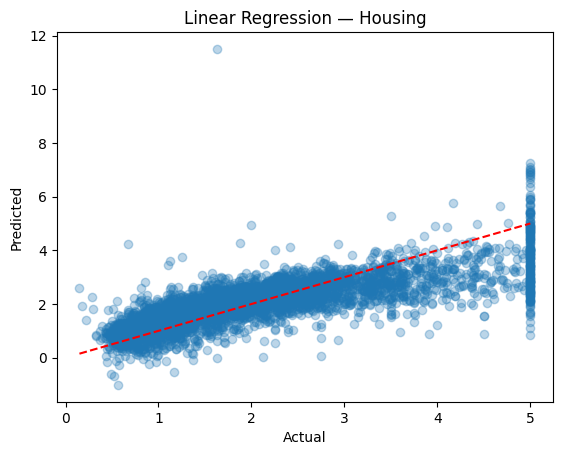

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target  # target = median house value

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
print('R²  :', r2_score(y_test, y_pred))
print('MSE :', mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

# Coefficient interpretation
coef_df = pd.DataFrame({'feature': X.columns, 'coef': model.coef_})
coef_df = coef_df.reindex(coef_df.coef.abs().sort_values(ascending=False).index)
print(coef_df)

# Plot predicted vs actual
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Linear Regression — Housing')
plt.show()